<a href="https://colab.research.google.com/github/Jalilelibrahimi/A-deep-learning-based-model-for-brain-tumors-detection/blob/main/ResNet50_neutrosophy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint,TensorBoard,LambdaCallback
from keras.layers import Input,Dropout, Dense,GlobalAveragePooling2D
from keras.models import Sequential,Model
from keras.applications.resnet import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow as tf
from tqdm import tqdm
import seaborn as sns
import numpy as np
import itertools
import datetime

import cv2
import os
import io

In [ ]:
import kagglehub

# Download latest version
# path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1


In [ ]:
train_dir = path + '/Training'
test_dir = path + '/Testing'

In [ ]:
import os
import shutil
import cv2
import numpy as np


def calc_I(data, p=3, q=3):
    kernel = np.ones((p, p), np.float32) / q
    dataMean = cv2.filter2D(data, -1, kernel)
    deltaMean = np.abs(data - dataMean)
    deltaMin = np.min(deltaMean)
    deltaMax = np.max(deltaMean)
    I = (deltaMean - deltaMin) / (deltaMax - deltaMin)
    return I

def Neutrosophic(img, p=3, m=5):
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gMean = cv2.blur(img, (p, p))
    gMin = np.min(gMean)
    gMax = np.max(gMean)
    T = (gMean - gMin) / (gMax - gMin)
    I = 1- calc_I(img)
    F = 1 - T
    return T*255,I*255,F*255

def combine_to_rgb(T, I, F):
    T = cv2.normalize(T, None, 0, 1, cv2.NORM_MINMAX)
    I = cv2.normalize(I, None, 0, 1, cv2.NORM_MINMAX)
    F = cv2.normalize(F, None, 0, 1, cv2.NORM_MINMAX)
    T_8bit = (T * 255).astype(np.uint8)
    I_8bit = (I * 255).astype(np.uint8)
    F_8bit = (F * 255).astype(np.uint8)
    rgb_image = cv2.merge((F_8bit, I_8bit, T_8bit))
    return rgb_image

In [ ]:


labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
# labels = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']

x_train = [] # training images.
y_train  = [] # training labels.
x_test = [] # testing images.
y_test = [] # testing labels.

image_size = 200


for label in labels:
    trainPath = os.path.join(path + '/Training',label)
    for file in tqdm(os.listdir(trainPath)):
        image = cv2.imread(os.path.join(trainPath, file),0) # load images in gray.
        # image = cv2.bilateralFilter(image, 2, 50, 50) # remove images noise.
        # image = cv2.applyColorMap(image, cv2.COLORMAP_BONE) # produce a pseudocolored image.
        t,i,f = Neutrosophic(image)
        image = combine_to_rgb(t,t,t)
        image = cv2.resize(image, (image_size, image_size)) # resize images into 150*150.
        x_train.append(image)
        y_train.append(labels.index(label))

    testPath = os.path.join(path +'/Testing',label)
    for file in tqdm(os.listdir(testPath)):
        image = cv2.imread(os.path.join(testPath, file),0)
        t,i,f = Neutrosophic(image)
        # image = combine_to_rgb(t,t,t)
        # image = cv2.bilateralFilter(image, 2, 50, 50)
        # image = cv2.applyColorMap(image, cv2.COLORMAP_BONE)
        image = cv2.resize(image, (image_size, image_size))
        x_test.append(image)
        y_test.append(labels.index(label))




100%|██████████| 300/300 [00:01<00:00, 160.77it/s]


In [ ]:
x_train = np.array(x_train) / 255.0 # normalize Images into range 0 to 1.
x_test = np.array(x_test) / 255.0

print(x_train.shape)
print(x_test.shape)

(5712, 200, 200, 3)
(1311, 200, 200, 3)


In [ ]:
x_train, y_train = shuffle(x_train,y_train, random_state=42)

y_train = tf.keras.utils.to_categorical(y_train) #One Hot Encoding on the labels
y_test = tf.keras.utils.to_categorical(y_test)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42) #Dividing the dataset into Training and Validation sets.

print(x_val.shape)

(1143, 200, 200, 3)


In [ ]:
# # Parameters
img_height, img_width = 200, 200
batch_size = 20
num_classes = 4

# train_datagen = ImageDataGenerator(
#     rotation_range=10,
#     width_shift_range=0.05,
#     height_shift_range=0.05,
#     horizontal_flip=True,
#     validation_split=0.2)


In [ ]:
net = ResNet50(
    weights='imagenet', # Load weights pre-trained on ImageNet.
     include_top=False, # Do not include the ImageNet classifier at the top.
     input_shape=(img_height,img_width,3))

model = net.output
model = Dense(64, activation='relu')(model)
model = GlobalAveragePooling2D()(model)

model = Dropout(0.4)(model)
model = Dense(4, activation="softmax")(model)
model = Model(inputs= net.input, outputs= model)

#compile our model.
adam = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=adam, loss = 'categorical_crossentropy', metrics=['accuracy'])
# model.summary()


In [ ]:
# Callbacks
checkpoint = ModelCheckpoint(
    "brain_tumor_classifier_N.weights.h5",  # Changed the filepath to end with .weights.h5
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1,
    save_weights_only=True # add this line to just save weights
)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=1)

# Train the model

In [ ]:
import time

start_time = time.time()

# Your model.fit code here
history = model.fit(
    x_train,
    y_train,
    batch_size=40,
    validation_data=(x_val, y_val),
    epochs=20,
    callbacks=[checkpoint, early_stopping]
)

end_time = time.time()

execution_time = end_time - start_time

# print(f"Model fitting execution time: {execution_time} seconds")

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.7778 - loss: 0.6093
Epoch 1: val_accuracy improved from -inf to 0.20560, saving model to brain_tumor_classifier_N.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 94s 322ms/step - accuracy: 0.7786 - loss: 0.6070 - val_accuracy: 0.2056 - val_loss: 1.7704
Epoch 2/20
114/115 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9741 - loss: 0.0838
Epoch 2: val_accuracy improved from 0.20560 to 0.27559, saving model to brain_tumor_classifier_N.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.9741 - loss: 0.0839 - val_accuracy: 0.2756 - val_loss: 1.7840
Epoch 3/20
114/115 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9876 - loss: 0.0358
Epoch 3: val_accuracy improved from 0.27559 to 0.28521, saving model to brain_tumor_classifier_N.weights.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.9876 - loss: 0.0358 - val_accuracy: 0.2852 - val_loss: 1.7830
Epoch 4/20
114/115 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accura

In [ ]:
seconds = end_time - start_time
minutes = seconds / 60
print(f"{seconds} seconds is equal to {minutes:.2f} minutes")

433.5337381362915 seconds is equal to 7.23 minutes


In [ ]:
model.load_weights("brain_tumor_classifier_N.weights.h5")

In [ ]:
loss,acc = model.evaluate(x_test,y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9911 - loss: 0.0323


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming you have already loaded weights
# model.load_weights("brain_tumor_classifier.weights.h5")

# Make predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert predictions to class labels
y_true_classes = np.argmax(y_test, axis=1)  # Convert true labels to class labels

# Calculate accuracy
accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Calculate precision
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')  # Use weighted average for multi-class
print(f"Precision: {precision:.4f}")

# Calculate recall
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')  # Use weighted average for multi-class
print(f"Recall: {recall:.4f}")
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')  # Use weighted average for multi-class
print(f"F1-score: {f1:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Accuracy: 0.9924
Precision: 0.9924
Recall: 0.9924
F1-score: 0.9924


In [ ]:
labels = ['Glioma', 'Meningioma', 'No-tumor', 'Pituitary']

Confusion matrix, without normalization


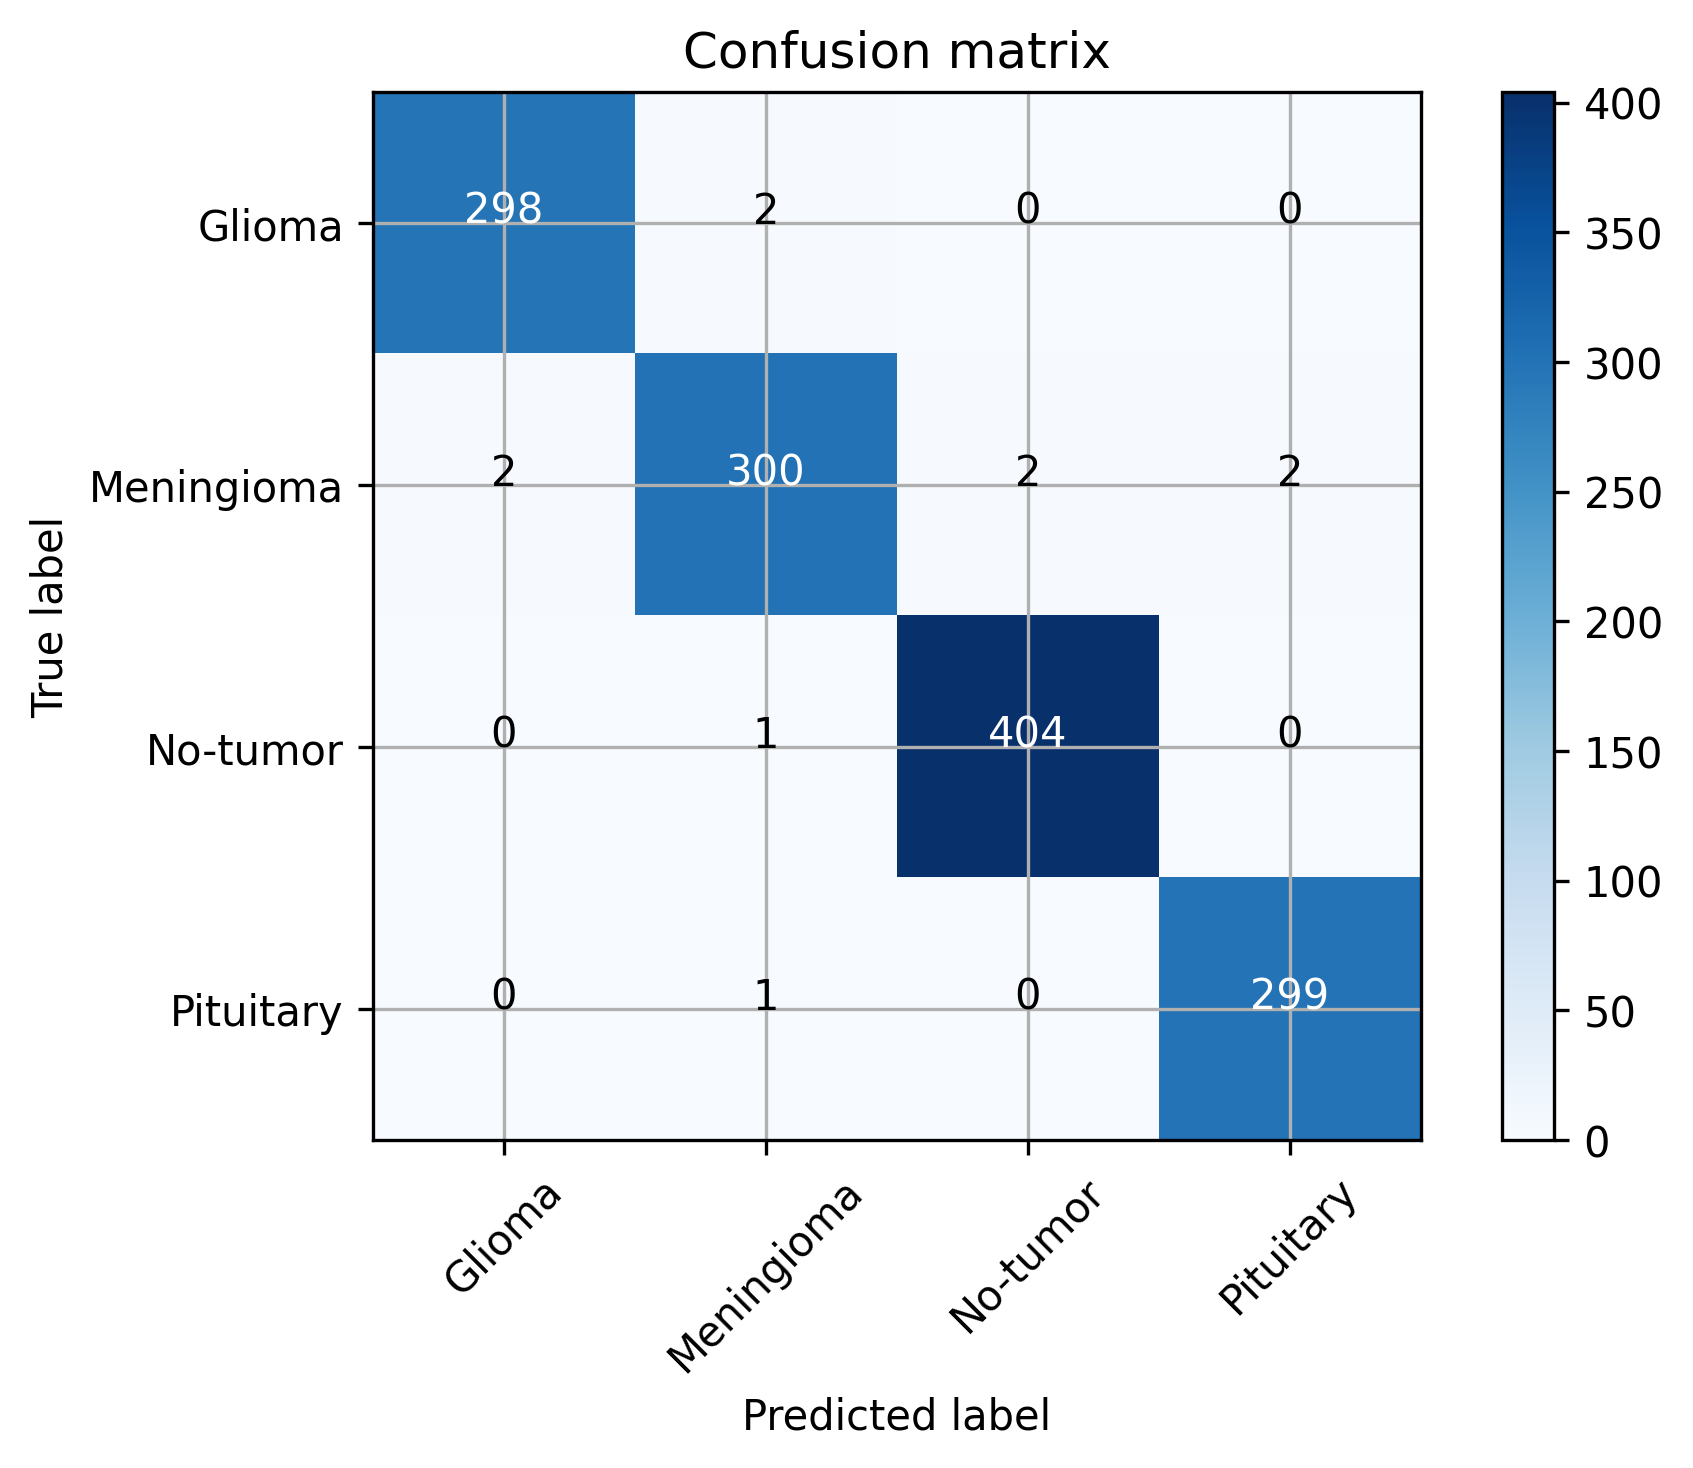

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix,classification_report
import numpy as np
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    # print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    # Assuming you have already computed the confusion matrix 'cm' and have 'labels'
cm = confusion_matrix(y_true_classes, y_pred_classes)
plot_confusion_matrix(cm, labels)  # labels are your class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
plt.rcParams['figure.dpi'] = 300
plt.grid(True)
plt.show()

In [ ]:
# get_ipython().magic('reset -sf')

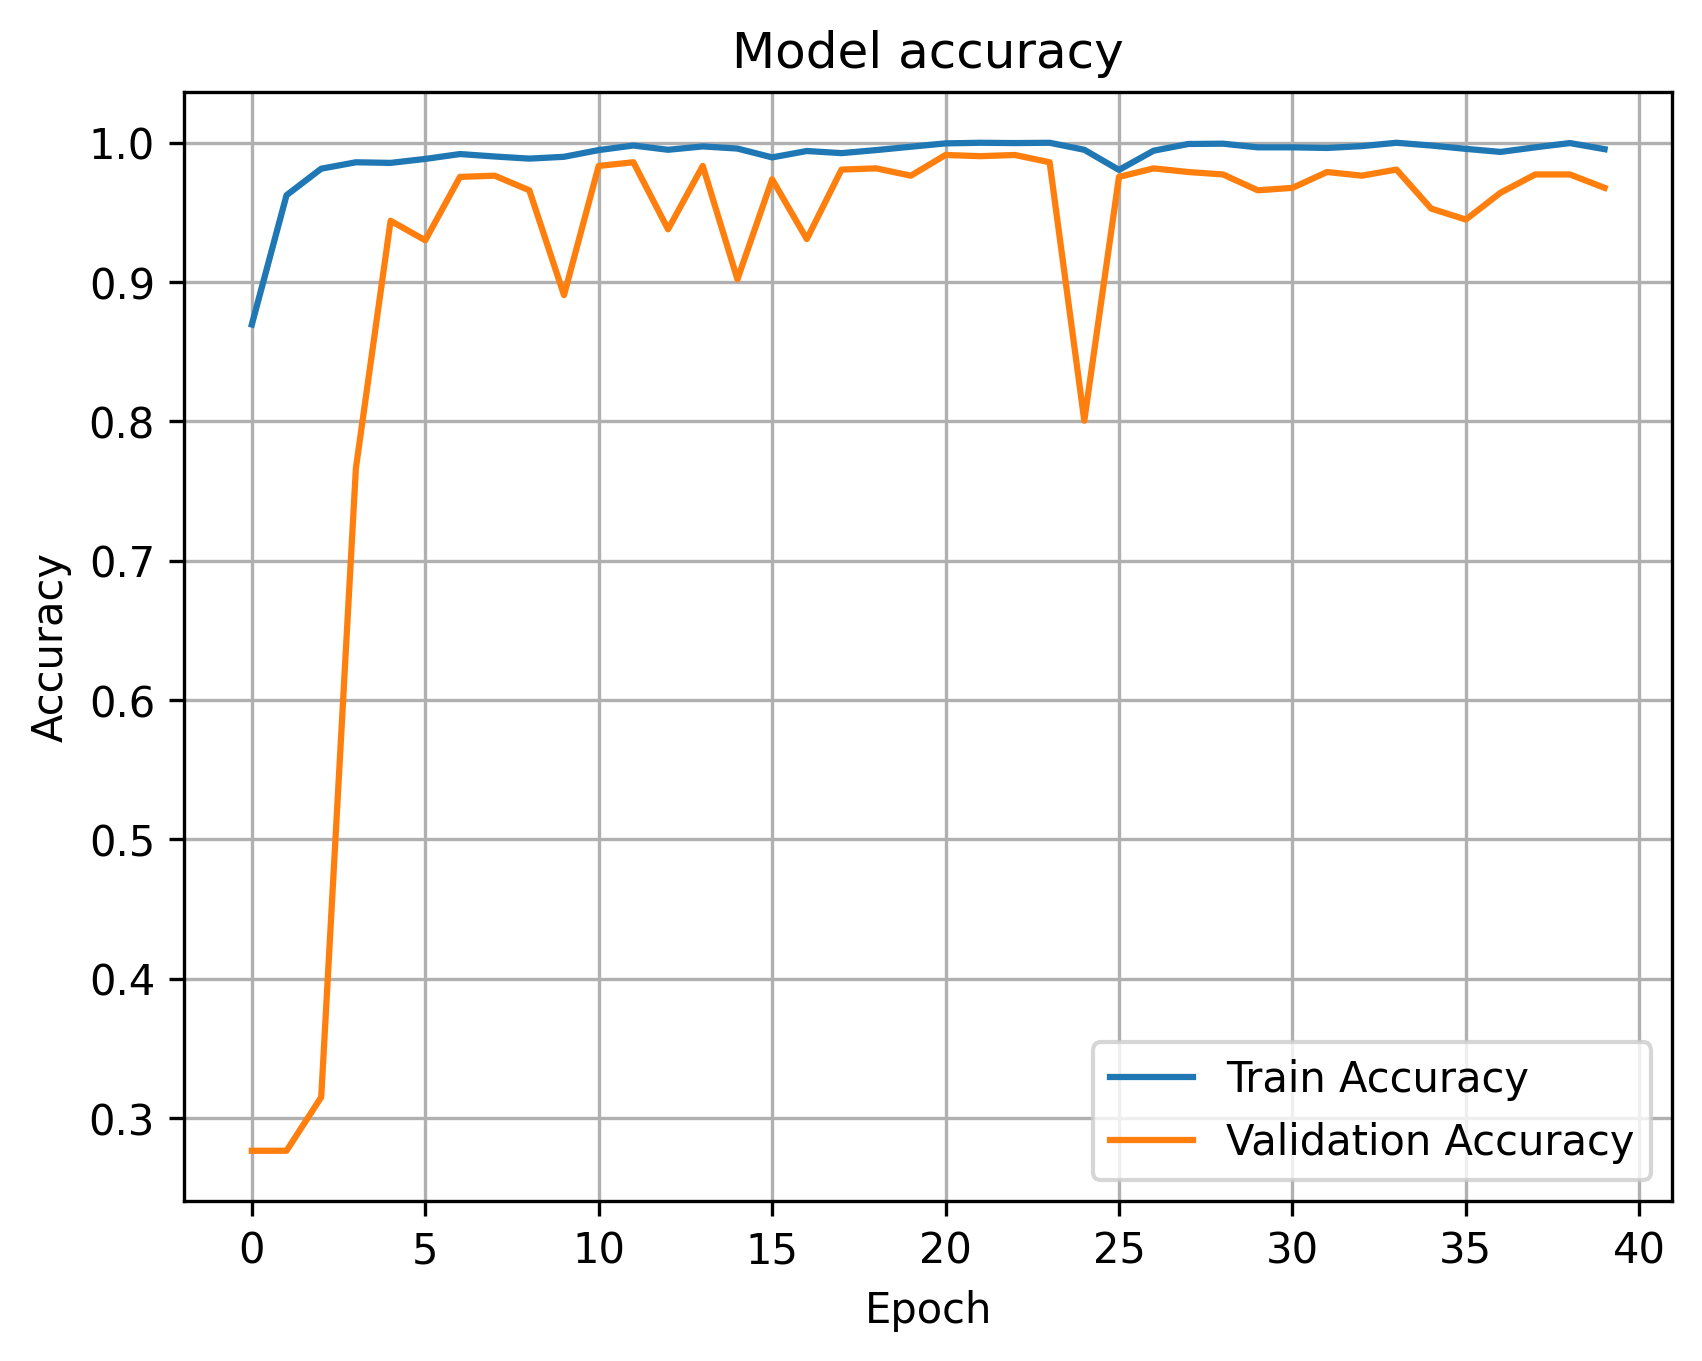

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'history' is the variable returned by model.fit
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy', 'Validation Accuracy'], loc='lower right')
plt.grid(True)
plt.rcParams['figure.dpi'] = 300  # Set DPI to 300

plt.show()

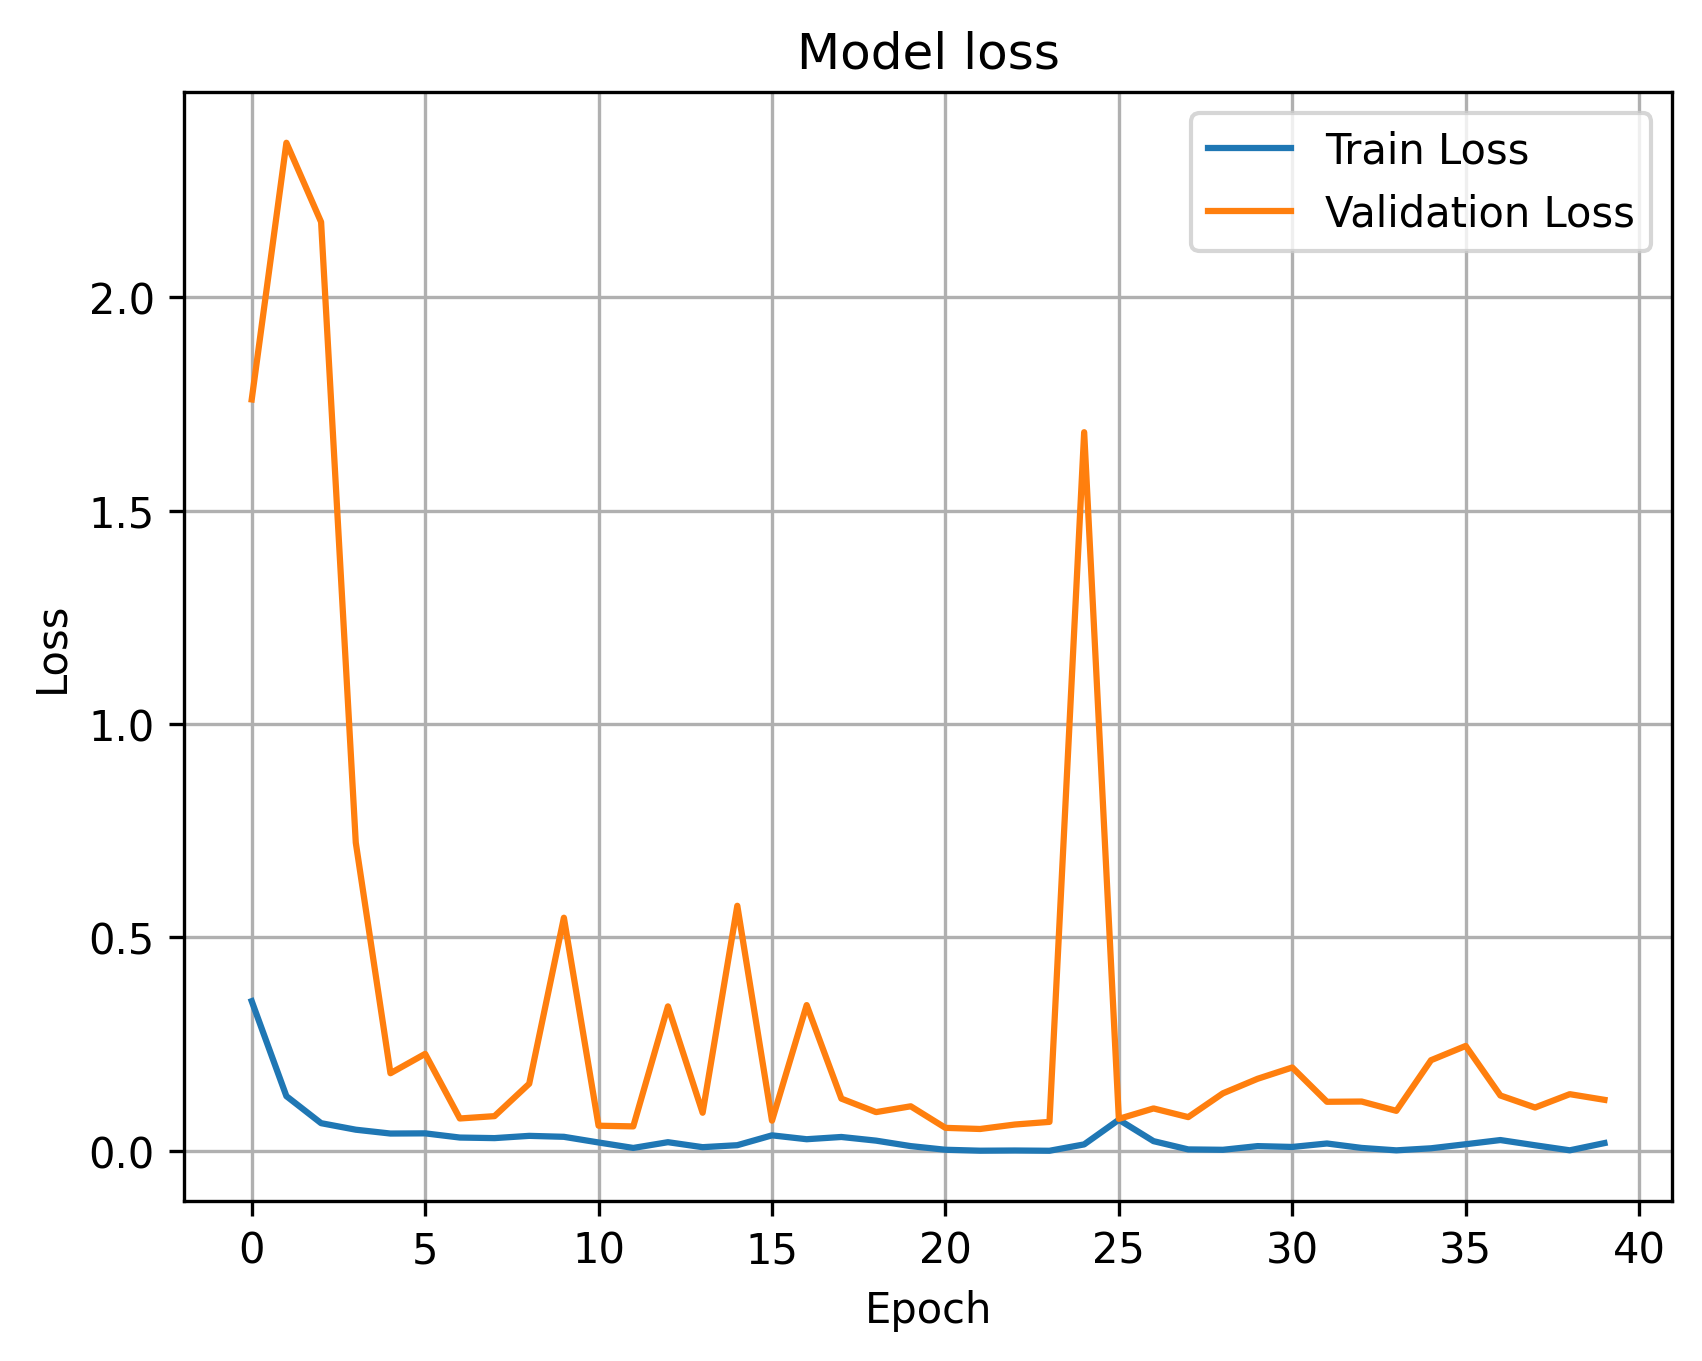

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss', 'Validation Loss'], loc='upper right')
plt.grid(True)  # Add a grid for better visualization
plt.rcParams['figure.dpi'] = 300  # Set DPI to 300 for higher resolution
plt.show()